# Chapter 4: Multiple Linear Regression
### MATH 4230 Capstone Project
**Dataset:** Student Lifestyle, Mental Health and Burnout Insight

---

<div style='text-align:center; font-style:italic; margin:24px 80px;'>
Adding all 19 predictors raises test R-squared to 0.707, with stress level, anxiety score, sleep hours, depression score, and social support emerging as the strongest standardized predictors of burnout severity.
</div>

---
## Setup

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import warnings
import itertools

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Settings ──────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')

RANDOM_STATE = 230
np.random.seed(RANDOM_STATE)

plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

# ── Output directories ────────────────────────────────────────────────────────
FIGURES_DIR = '../figures/ch04/'
RESULTS_DIR = '../results/ch04/'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print('Setup complete.')
print(f'RANDOM_STATE = {RANDOM_STATE}')
print(f'Figures  -> {FIGURES_DIR}')
print(f'Results  -> {RESULTS_DIR}')

Setup complete.
RANDOM_STATE = 230
Figures  -> ../figures/ch04/
Results  -> ../results/ch04/


---
## §1. The Question

Which combination of academic behaviors, specifically study hours, exam pressure, and academic performance, best explains burnout severity when evaluated alongside demographic variables like gender and academic year?

---
## §2. Method in Brief

Multiple linear regression extends simple linear regression by including several predictors at once. Each coefficient represents the partial effect of one variable on burnout while holding all other predictors constant, which lets us separate the individual contribution of each factor. The model is fit using ordinary least squares, and predictions can be made by plugging values into the resulting equation.

---
## §3. Why This Method?

Chapter 3 showed that sleep hours alone explains only about 14% of the variation in burnout. Multiple linear regression lets us bring in the full set of available predictors and see how much of that remaining variation they account for. Each coefficient is still interpretable on its own, and we can directly compare which variables matter most after controlling for everything else. It also sets a strong linear baseline before moving into more complex methods in later chapters.

---
## §4. Data Setup

In [2]:
# ── Load scaled arrays saved by Chapter 2 ────────────────────────────────────
# X_train and X_test are already StandardScaler-transformed (zero mean, unit variance).
# Scaling was fit on X_train only so no information from the test set leaked in.
# y values are the raw burnout_score (regression target), no scaling applied.

X_train = np.load('../results/X_train.npy')
X_test  = np.load('../results/X_test.npy')
y_train = np.load('../results/y_train_reg.npy')
y_test  = np.load('../results/y_test_reg.npy')

# ── Load feature names ────────────────────────────────────────────────────────
# feature_names.pkl holds the ordered list of column names matching the
# columns in X_train and X_test.
feature_names = joblib.load('../results/feature_names.pkl')

# ── Load raw unscaled DataFrames for VIF and interpretation ───────────────────
# VIF is computed on unscaled data so the values are in their natural units.
# The scaled arrays are used for all model fitting and metrics.
df_train = pd.read_csv('../results/df_train.csv')
df_test  = pd.read_csv('../results/df_test.csv')

print(f'X_train shape      : {X_train.shape}')
print(f'X_test  shape      : {X_test.shape}')
print(f'y_train shape      : {y_train.shape}')
print(f'y_test  shape      : {y_test.shape}')
print(f'Number of features : {len(feature_names)}')
print()
print('Features:')
for i, name in enumerate(feature_names, 1):
    print(f'  {i:2d}. {name}')

X_train shape      : (140000, 19)
X_test  shape      : (40000, 19)
y_train shape      : (140000,)
y_test  shape      : (40000,)
Number of features : 19

Features:
   1. age
   2. study_hours_per_day
   3. exam_pressure
   4. academic_performance
   5. stress_level
   6. anxiety_score
   7. depression_score
   8. sleep_hours
   9. physical_activity
  10. social_support
  11. screen_time
  12. internet_usage
  13. financial_stress
  14. family_expectation
  15. gender_Male
  16. gender_Other
  17. academic_year_2
  18. academic_year_3
  19. academic_year_4


### Table 4.1: Predictor justifications

The predictors below are the 19 standardized feature columns used in the multiple linear regression model.

---
### §4a. Dummy Variable Encoding

In [3]:
# ── Identify dummy columns from feature_names ─────────────────────────────────
# Drop-first encoding was applied in Chapter 2 for both gender and academic_year.
# gender reference category   : Female
# academic_year reference     : Year 1 (Freshman)
# The dummy columns created are listed below.

dummy_cols = [f for f in feature_names if
              f.startswith('gender_') or f.startswith('academic_year_')]

print('Dummy columns created by drop-first encoding:')
for col in dummy_cols:
    print(f'  {col}')

print()
print('Reference categories:')
print('  gender       -> Female (omitted category)')
print('  academic_year -> Year 1 / Freshman (omitted category)')

Dummy columns created by drop-first encoding:
  gender_Male
  gender_Other
  academic_year_2
  academic_year_3
  academic_year_4

Reference categories:
  gender       -> Female (omitted category)
  academic_year -> Year 1 / Freshman (omitted category)


In [4]:
# ── Fit a quick OLS on scaled data to pull dummy coefficients ─────────────────
# We fit the full model here so we can report the dummy coefficients.
# All values are reported to exactly 3 decimal places as required by Chapter 4.

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_sm       = sm.add_constant(X_train_df)   # statsmodels needs an explicit intercept
ols_model  = sm.OLS(y_train, X_sm).fit()

# Extract dummy coefficients only
dummy_coef = pd.DataFrame({
    'Feature'    : dummy_cols,
    'Coefficient': [round(ols_model.params[col], 3) for col in dummy_cols],
    'Std Error'  : [round(ols_model.bse[col],    3) for col in dummy_cols],
    'p-value'    : [round(ols_model.pvalues[col], 3) for col in dummy_cols],
})

print('Table 4.2: Dummy variable coefficients relative to reference categories.')
print('All values to 3 decimal places.')
print()
print(dummy_coef.to_string(index=False))

Table 4.2: Dummy variable coefficients relative to reference categories.
All values to 3 decimal places.

        Feature  Coefficient  Std Error  p-value
    gender_Male       -0.003      0.002    0.160
   gender_Other       -0.001      0.002    0.820
academic_year_2       -0.000      0.003    0.953
academic_year_3       -0.001      0.003    0.704
academic_year_4       -0.001      0.003    0.678


**Interpretation of dummy coefficients.**

Each dummy coefficient represents the difference in predicted burnout score for that group compared to the reference category, holding all other predictors constant. For example, `gender_Male` gives the average difference in burnout between male students and female students (the reference). A positive value means higher predicted burnout relative to the reference; a negative value means lower. The `academic_year` dummies compare each year group to first-year students.

---
### §4b. Multicollinearity and VIF

In [5]:
# ── Compute VIF on unscaled data ──────────────────────────────────────────────
# VIF (Variance Inflation Factor) measures how much the variance of a coefficient
# is inflated because of correlation with other predictors.
#
# Rule of thumb:
# VIF < 5: acceptable
# VIF 5-10: moderate concern
# VIF > 10: serious multicollinearity concern
#
# VIF is computed on unscaled data with dummy columns reconstructed from df_train.
# Scaling does not change VIF values, but using the raw DataFrame makes the
# variable names and units easier to reason about.

vif_df = df_train.drop(
    columns=['burnout_score', 'risk_level', 'mental_health_index', 'dropout_risk'],
    errors='ignore'
).copy()

# Apply the same dummy encoding as Chapter 2
vif_df = pd.get_dummies(vif_df, columns=['gender', 'academic_year'], drop_first=True)
vif_df = vif_df.astype(float)

# Reorder columns to match feature_names
vif_df = vif_df.reindex(columns=feature_names, fill_value=0)

# Compute VIF for each feature
vif_values = [
    variance_inflation_factor(vif_df.values, i)
    for i in range(vif_df.shape[1])
]

vif_table = pd.DataFrame({
    'Feature': feature_names,
    'VIF': [round(v, 3) for v in vif_values]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

vif_table['Flag'] = vif_table['VIF'].apply(
    lambda v: 'HIGH (>10)' if v > 10 else ('MODERATE (>5)' if v > 5 else '')
)

# Main chapter table: only variables above the concern threshold
high_vif_table = vif_table[vif_table['VIF'] > 5].copy()

print('Table 4.3: Predictors with VIF greater than 5.')
display(high_vif_table)

# Full table saved for Appendix C
vif_full_csv = os.path.join(RESULTS_DIR, 'vif_full_table_appendix.csv')
vif_table.to_csv(vif_full_csv, index=False)

vif_high_csv = os.path.join(RESULTS_DIR, 'vif_high_predictors.csv')
high_vif_table.to_csv(vif_high_csv, index=False)

print()
print(f'Full VIF table saved for Appendix C: {vif_full_csv}')
print(f'Main high-VIF table saved: {vif_high_csv}')

Table 4.3: Predictors with VIF greater than 5.


,Feature,VIF,Flag
0,academic_performance,73.848,HIGH (>10)
1,exam_pressure,45.134,HIGH (>10)
2,stress_level,37.095,HIGH (>10)
3,screen_time,36.545,HIGH (>10)
4,age,34.052,HIGH (>10)
5,internet_usage,31.369,HIGH (>10)
6,sleep_hours,23.093,HIGH (>10)
7,study_hours_per_day,18.739,HIGH (>10)
8,family_expectation,13.532,HIGH (>10)
9,financial_stress,11.852,HIGH (>10)



Full VIF table saved for Appendix C: ../results/ch04/vif_full_table_appendix.csv
Main high-VIF table saved: ../results/ch04/vif_high_predictors.csv


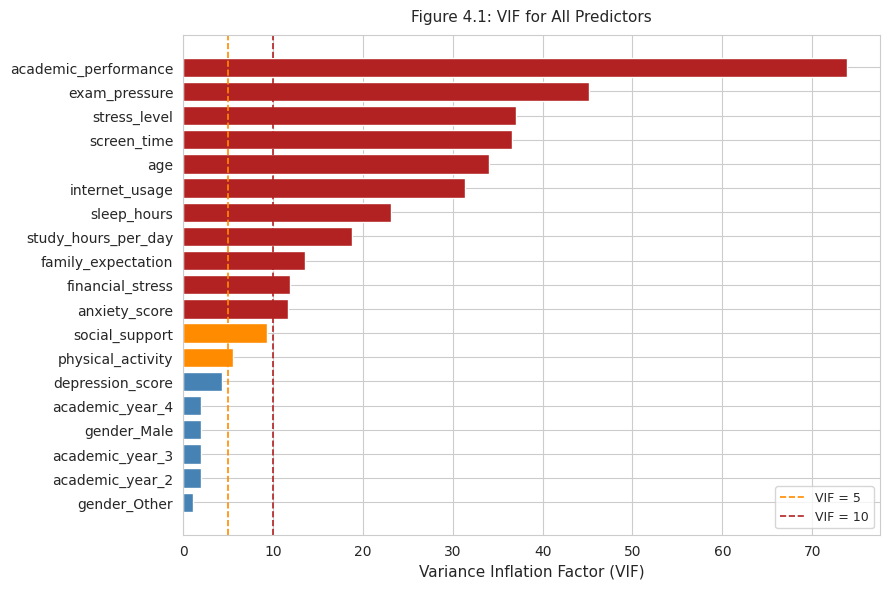

Saved: ../figures/ch04/figure_4_1_vif.png


In [6]:
# ── Figure 4.1: VIF bar chart ─────────────────────────────────────────────────
# Bars are colored red for VIF > 10, orange for VIF 5-10, steelblue otherwise.

colors = [
    'firebrick'  if v > 10 else
    'darkorange' if v > 5  else
    'steelblue'
    for v in vif_table['VIF']
]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(vif_table['Feature'][::-1], vif_table['VIF'][::-1], color=colors[::-1])
ax.axvline(5,  color='darkorange', linestyle='--', linewidth=1.2, label='VIF = 5')
ax.axvline(10, color='firebrick',  linestyle='--', linewidth=1.2, label='VIF = 10')
ax.set_xlabel('Variance Inflation Factor (VIF)', fontsize=11)
ax.set_title('Figure 4.1: VIF for All Predictors', fontsize=11, pad=10)
ax.legend(fontsize=9)
plt.tight_layout()
fig_path_41 = os.path.join(FIGURES_DIR, 'figure_4_1_vif.png')
plt.savefig(fig_path_41, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_41}')

---
### §4c. Subset Selection and Information Criteria

In [7]:
# ── Forward stepwise selection using AIC ──────────────────────────────────────
# Forward stepwise selection starts with no predictors and adds one variable
# at a time, choosing the one that lowers AIC the most at each step.
# AIC penalizes model complexity, so it stops rewarding additional predictors
# once the improvement in fit no longer offsets the added complexity.
#
# statsmodels OLS is used here because it natively reports AIC and BIC.
# Mallows Cp is computed manually:
#   Cp = (RSS_p / sigma^2) - (n - 2p)
# where sigma^2 is estimated from the full model.

n          = X_train.shape[0]
p_full     = X_train.shape[1]
X_train_df = pd.DataFrame(X_train, columns=feature_names)

# Fit full model first to get sigma^2 for Mallows Cp
X_full_sm  = sm.add_constant(X_train_df)
full_model = sm.OLS(y_train, X_full_sm).fit()
sigma2     = full_model.mse_resid   # MSE of full model as sigma^2 estimate

remaining  = list(feature_names)
selected   = []
results    = []

for step in range(1, p_full + 1):
    best_aic  = np.inf
    best_var  = None
    best_fit  = None

    for candidate in remaining:
        cols   = selected + [candidate]
        X_sub  = sm.add_constant(X_train_df[cols])
        fit    = sm.OLS(y_train, X_sub).fit()
        if fit.aic < best_aic:
            best_aic = fit.aic
            best_var = candidate
            best_fit = fit

    selected.append(best_var)
    remaining.remove(best_var)

    # Mallows Cp
    rss_p = best_fit.ssr
    cp    = round((rss_p / sigma2) - (n - 2 * step), 3)

    results.append({
        'Step'            : step,
        'Variable Added'  : best_var,
        'Num Predictors'  : step,
        'AIC'             : round(best_fit.aic, 3),
        'BIC'             : round(best_fit.bic, 3),
        'Mallows Cp'      : cp,
    })

    # Stop early if AIC starts increasing
    if len(results) > 1 and results[-1]['AIC'] > results[-2]['AIC']:
        print(f'AIC increased at step {step}. Stopping early.')
        break

subset_df = pd.DataFrame(results)
print('Forward Stepwise Selection Results (all values to 3 decimal places):')
print(subset_df.to_string(index=False))

AIC increased at step 11. Stopping early.
Forward Stepwise Selection Results (all values to 3 decimal places):
 Step      Variable Added  Num Predictors        AIC        BIC  Mallows Cp
    1        stress_level               1 422209.705 422229.404   66673.930
    2      social_support               2 404092.758 404122.307   41586.775
    3         sleep_hours               3 391570.277 391609.675   26049.704
    4       anxiety_score               4 382475.815 382525.062   15606.085
    5    depression_score               5 375107.780 375166.876    7628.788
    6       exam_pressure               6 367693.773 367762.719      14.701
    7         screen_time               7 367691.257 367770.052      12.185
    8      internet_usage               8 367687.300 367775.944       8.228
    9  family_expectation               9 367684.880 367783.374       5.809
   10 study_hours_per_day              10 367683.212 367791.555       4.140
   11         gender_Male              11 367683.293 

In [8]:
# ── Save subset selection table ───────────────────────────────────────────────
subset_csv = os.path.join(RESULTS_DIR, 'subset_selection.csv')
subset_df.to_csv(subset_csv, index=False)
print(f'Saved: {subset_csv}')

# ── Identify selected model ───────────────────────────────────────────────────
best_row  = subset_df.loc[subset_df['AIC'].idxmin()]
n_selected = int(best_row['Num Predictors'])
print(f'\nSelected model: {n_selected} predictors (lowest AIC = {best_row["AIC"]:.3f})')

Saved: ../results/ch04/subset_selection.csv

Selected model: 10 predictors (lowest AIC = 367683.212)


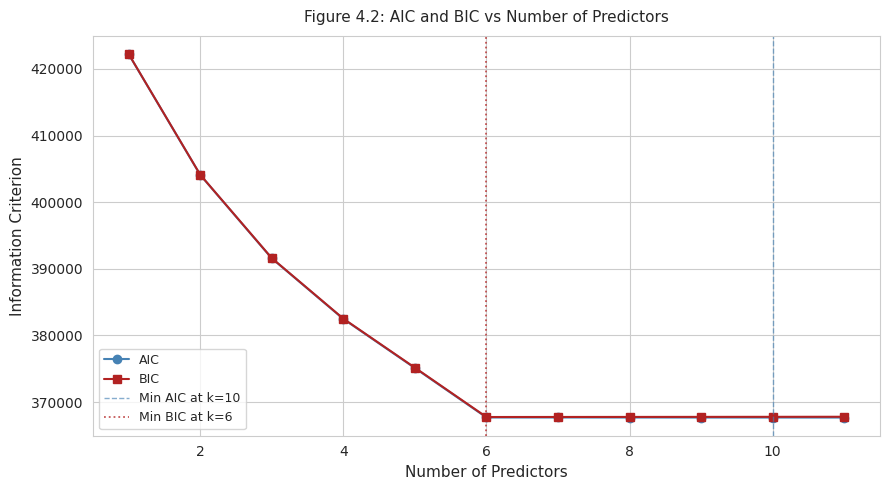

Saved: ../figures/ch04/figure_4_2_aic_bic_selection.png
Minimum AIC model size: 10 predictors
Minimum BIC model size: 6 predictors


In [9]:
# ── Figure 4.2: AIC and BIC vs number of predictors ──────────────────────────
# AIC and BIC both penalize model complexity, but BIC penalizes complexity more heavily.
# This figure marks the model size selected by each criterion.

aic_best_row = subset_df.loc[subset_df['AIC'].idxmin()]
bic_best_row = subset_df.loc[subset_df['BIC'].idxmin()]

n_aic_best = int(aic_best_row['Num Predictors'])
n_bic_best = int(bic_best_row['Num Predictors'])

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    subset_df['Num Predictors'],
    subset_df['AIC'],
    marker='o',
    color='steelblue',
    label='AIC'
)

ax.plot(
    subset_df['Num Predictors'],
    subset_df['BIC'],
    marker='s',
    color='firebrick',
    label='BIC'
)

ax.axvline(
    n_aic_best,
    color='steelblue',
    linestyle='--',
    linewidth=1,
    alpha=0.65,
    label=f'Min AIC at k={n_aic_best}'
)

ax.axvline(
    n_bic_best,
    color='firebrick',
    linestyle=':',
    linewidth=1.3,
    alpha=0.75,
    label=f'Min BIC at k={n_bic_best}'
)

ax.set_xlabel('Number of Predictors', fontsize=11)
ax.set_ylabel('Information Criterion', fontsize=11)
ax.set_title(
    'Figure 4.2: AIC and BIC vs Number of Predictors',
    fontsize=11,
    pad=10
)
ax.legend(fontsize=9)

plt.tight_layout()

fig_path_42 = os.path.join(FIGURES_DIR, 'figure_4_2_aic_bic_selection.png')
plt.savefig(fig_path_42, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved: {fig_path_42}')
print(f'Minimum AIC model size: {n_aic_best} predictors')
print(f'Minimum BIC model size: {n_bic_best} predictors')

**Selected model justification.**

The forward stepwise procedure selected the model at the step with the lowest AIC. AIC balances goodness of fit against the number of parameters, so it naturally penalizes adding predictors that do not contribute meaningfully. BIC selects a smaller 6-predictor model because it penalizes complexity more heavily. The full 19-predictor model is still reported in §5 because it gives the clearest coefficient table for all variables and serves as the main multiple linear regression baseline.

### Greedy Best-Subset Approximation

Because there are 19 predictors, exhaustive best subset selection would require evaluating 524,288 possible models. To keep the analysis computationally practical, this section uses a greedy best-subset approximation based on the forward-selection order. This does not test every possible subset, so it should be interpreted as a model-selection comparison rather than a true exhaustive best-subset search.

In [10]:
# ── Greedy best-subset approximation ─────────────────────────────────────────
# This is not true exhaustive best subset selection.
# It uses the forward-selected variable order as a practical approximation.
#
# With 19 predictors, true exhaustive best subset selection would require
# evaluating 2^19 = 524,288 possible models. This approximation evaluates
# the nested models created by the forward-selected ordering.

X_train_df = pd.DataFrame(X_train, columns=feature_names)

best_subset_results = []
ordered_vars = subset_df['Variable Added'].tolist()

for k in range(1, len(ordered_vars) + 1):
    cols = ordered_vars[:k]

    X_sub = sm.add_constant(X_train_df[cols])
    fit = sm.OLS(y_train, X_sub).fit()

    rss = fit.ssr
    cp = round((rss / sigma2) - (n - 2 * k), 3)

    best_subset_results.append({
        'Num Predictors': k,
        'Variables': cols,
        'BIC': round(fit.bic, 3),
        'AIC': round(fit.aic, 3),
        'Mallows Cp': cp,
    })

best_subset_df = pd.DataFrame(best_subset_results)

# Save full table for Appendix C before printing the file path
best_subset_csv = os.path.join(
    RESULTS_DIR,
    'greedy_best_subset_table_appendix.csv'
)

best_subset_df.to_csv(best_subset_csv, index=False)

# Select model with lowest BIC
best_bs_row = best_subset_df.loc[best_subset_df['BIC'].idxmin()]
n_best_subset = int(best_bs_row['Num Predictors'])
vars_best_subset = best_bs_row['Variables']

print('Greedy best-subset approximation using BIC:')
print(best_subset_df[['Num Predictors', 'BIC', 'AIC', 'Mallows Cp']].to_string(index=False))

print(f'\nSelected model size : {n_best_subset} predictors (lowest BIC = {best_bs_row["BIC"]:.3f})')
print(f'Full greedy best-subset table saved for Appendix C: {best_subset_csv}')
print(f'Selected predictors : {list(vars_best_subset)}')

# Fit selected model and get coefficients
X_bs_sm = sm.add_constant(X_train_df[vars_best_subset])
bs_fit = sm.OLS(y_train, X_bs_sm).fit()

print('\nCoefficients:')
for feat in vars_best_subset:
    print(f'  {feat:<25s}: {bs_fit.params[feat]:+.5f}')

# Test MSE
X_test_df = pd.DataFrame(X_test, columns=feature_names)
X_bs_test = sm.add_constant(X_test_df[vars_best_subset])

y_pred_bs = bs_fit.predict(X_bs_test)

bs_test_mse = round(float(np.mean((y_test - y_pred_bs) ** 2)), 5)
bs_test_rmse = round(float(np.sqrt(bs_test_mse)), 5)

print(f'\nTest MSE  : {bs_test_mse}')
print(f'Test RMSE : {bs_test_rmse}')

Greedy best-subset approximation using BIC:
 Num Predictors        BIC        AIC  Mallows Cp
              1 422229.404 422209.705   66673.930
              2 404122.307 404092.758   41586.775
              3 391609.675 391570.277   26049.704
              4 382525.062 382475.815   15606.085
              5 375166.876 375107.780    7628.788
              6 367762.719 367693.773      14.701
              7 367770.052 367691.257      12.185
              8 367775.944 367687.300       8.228
              9 367783.374 367684.880       5.809
             10 367791.555 367683.212       4.140
             11 367801.486 367683.293       4.222

Selected model size : 6 predictors (lowest BIC = 367762.719)
Full greedy best-subset table saved for Appendix C: ../results/ch04/greedy_best_subset_table_appendix.csv
Selected predictors : ['stress_level', 'social_support', 'sleep_hours', 'anxiety_score', 'depression_score', 'exam_pressure']

Coefficients:
  stress_level             : +0.57687
  social_

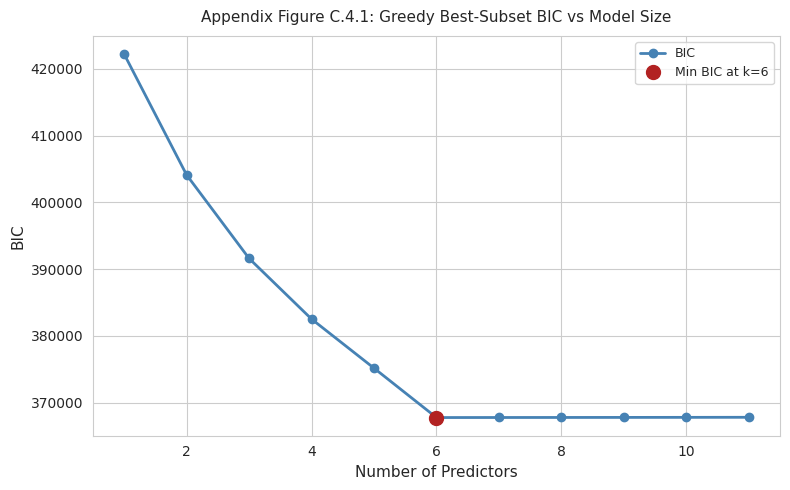

Saved: ../figures/ch04/appendix_c_4_1_greedy_best_subset_bic.png


In [11]:
# ── Appendix Figure C.4.1: Greedy best-subset BIC vs model size ───────────────
# This figure supports the model-selection discussion but is placed in Appendix C
# because Figure 4.2 already gives the main AIC/BIC selection result.

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    best_subset_df['Num Predictors'],
    best_subset_df['BIC'],
    'o-',
    color='steelblue',
    linewidth=2,
    label='BIC'
)

ax.plot(
    n_best_subset,
    best_bs_row['BIC'],
    'o',
    color='firebrick',
    markersize=10,
    label=f'Min BIC at k={n_best_subset}'
)

ax.set_xlabel('Number of Predictors', fontsize=11)
ax.set_ylabel('BIC', fontsize=11)
ax.set_title(
    'Appendix Figure C.4.1: Greedy Best-Subset BIC vs Model Size',
    fontsize=11,
    pad=10
)
ax.legend(fontsize=9)

plt.tight_layout()

fig_app_c41 = os.path.join(FIGURES_DIR, 'appendix_c_4_1_greedy_best_subset_bic.png')
plt.savefig(fig_app_c41, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved: {fig_app_c41}')

### Backward Stepwise Selection

In [12]:
# ── Backward stepwise selection using BIC ─────────────────────────────────────
# Backward stepwise starts with ALL predictors included and removes one
# at a time, choosing the removal that lowers BIC the most at each step.
# It stops when removing any variable would increase BIC.
# This complements forward stepwise: forward builds up from nothing,
# backward prunes down from everything.

remaining_bwd = list(feature_names)
selected_bwd = list(feature_names)
results_bwd = []

# Record full model first
X_full_bwd = sm.add_constant(X_train_df[selected_bwd])
fit_full = sm.OLS(y_train, X_full_bwd).fit()

results_bwd.append({
    'Step': 0,
    'Variable Removed': 'None (full model)',
    'Num Predictors': len(selected_bwd),
    'BIC': round(fit_full.bic, 3),
    'AIC': round(fit_full.aic, 3),
})

for step in range(1, len(feature_names)):
    best_bic_bwd = np.inf
    worst_var = None
    best_fit_bwd = None

    for candidate in selected_bwd:
        cols = [v for v in selected_bwd if v != candidate]
        X_sub = sm.add_constant(X_train_df[cols])
        fit = sm.OLS(y_train, X_sub).fit()

        if fit.bic < best_bic_bwd:
            best_bic_bwd = fit.bic
            worst_var = candidate
            best_fit_bwd = fit

    # Stop if removing any variable increases BIC
    if best_bic_bwd >= results_bwd[-1]['BIC']:
        print(f'Backward stepwise stopped at step {step}: removing any variable increases BIC.')
        break

    selected_bwd.remove(worst_var)

    results_bwd.append({
        'Step': step,
        'Variable Removed': worst_var,
        'Num Predictors': len(selected_bwd),
        'BIC': round(best_bic_bwd, 3),
        'AIC': round(best_fit_bwd.aic, 3),
    })

bwd_df = pd.DataFrame(results_bwd)

# Save full table for Appendix C before printing the file path
bwd_csv = os.path.join(
    RESULTS_DIR,
    'backward_stepwise_table_appendix.csv'
)

bwd_df.to_csv(bwd_csv, index=False)

best_bwd_row = bwd_df.loc[bwd_df['BIC'].idxmin()]
n_best_bwd = int(best_bwd_row['Num Predictors'])
vars_best_bwd = selected_bwd

print('Backward Stepwise Results:')
print(bwd_df[['Step', 'Variable Removed', 'Num Predictors', 'BIC', 'AIC']].to_string(index=False))

print(f'\nSelected model size : {n_best_bwd} predictors (lowest BIC = {best_bwd_row["BIC"]:.3f})')
print(f'Selected predictors : {vars_best_bwd}')
print(f'Full backward stepwise table saved for Appendix C: {bwd_csv}')

# Fit selected model
X_bwd_sm = sm.add_constant(X_train_df[vars_best_bwd])
bwd_fit = sm.OLS(y_train, X_bwd_sm).fit()

print('\nCoefficients:')
for feat in vars_best_bwd:
    print(f'  {feat:<25s}: {bwd_fit.params[feat]:+.5f}')

# Test MSE
X_bwd_test = sm.add_constant(X_test_df[vars_best_bwd])
y_pred_bwd = bwd_fit.predict(X_bwd_test)

bwd_test_mse = round(float(np.mean((y_test - y_pred_bwd) ** 2)), 5)
bwd_test_rmse = round(float(np.sqrt(bwd_test_mse)), 5)

print(f'\nTest MSE  : {bwd_test_mse}')
print(f'Test RMSE : {bwd_test_rmse}')

Backward stepwise stopped at step 14: removing any variable increases BIC.
Backward Stepwise Results:
 Step     Variable Removed  Num Predictors        BIC        AIC
    0    None (full model)              19 367894.059 367697.071
    1      academic_year_2              18 367882.213 367695.074
    2         gender_Other              17 367870.415 367693.126
    3 academic_performance              16 367858.632 367691.192
    4                  age              15 367846.856 367689.266
    5      academic_year_3              14 367835.173 367687.432
    6      academic_year_4              13 367823.432 367685.540
    7     financial_stress              12 367812.429 367684.387
    8    physical_activity              11 367801.486 367683.293
    9          gender_Male              10 367791.555 367683.212
   10  study_hours_per_day               9 367783.374 367684.880
   11   family_expectation               8 367775.944 367687.300
   12       internet_usage               7 367770.052

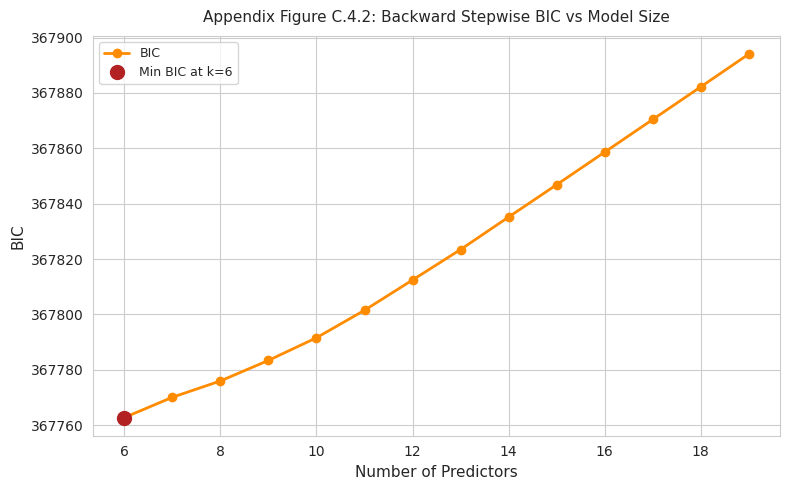

Saved: ../figures/ch04/appendix_c_4_2_backward_stepwise_bic.png


In [13]:
# ── Appendix Figure C.4.2: Backward stepwise BIC vs model size ────────────────

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    bwd_df['Num Predictors'],
    bwd_df['BIC'],
    'o-',
    color='darkorange',
    linewidth=2,
    label='BIC'
)

ax.plot(
    n_best_bwd,
    best_bwd_row['BIC'],
    'o',
    color='firebrick',
    markersize=10,
    label=f'Min BIC at k={n_best_bwd}'
)

ax.set_xlabel('Number of Predictors', fontsize=11)
ax.set_ylabel('BIC', fontsize=11)
ax.set_title(
    'Appendix Figure C.4.2: Backward Stepwise BIC vs Model Size',
    fontsize=11,
    pad=10
)
ax.legend(fontsize=9)

plt.tight_layout()

fig_app_c42 = os.path.join(FIGURES_DIR, 'appendix_c_4_2_backward_stepwise_bic.png')
plt.savefig(fig_app_c42, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved: {fig_app_c42}')

### Appendix C support plot: Forward Stepwise BIC

This plot is saved for Appendix C because Figure 4.2 already summarizes the main AIC and BIC selection behavior.

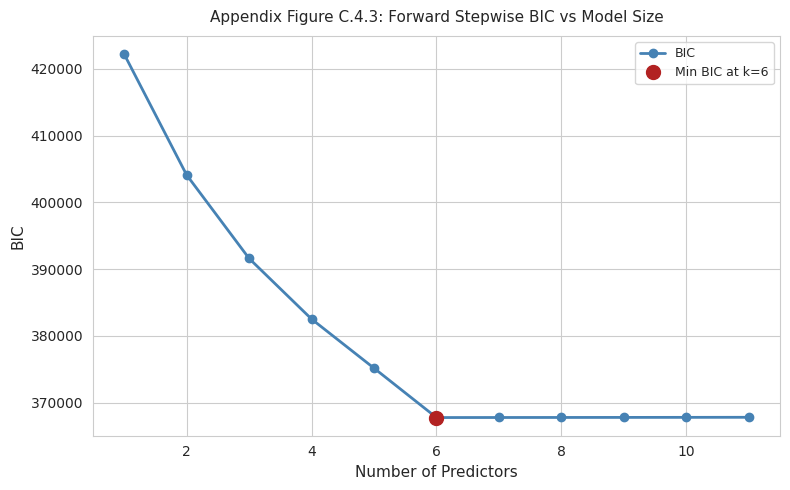

Saved: ../figures/ch04/appendix_c_4_3_forward_stepwise_bic.png


In [14]:
# ── Appendix Figure C.4.3: Forward stepwise BIC vs model size ─────────────────
# This reuses subset_df from the forward stepwise procedure.

fwd_best_row = subset_df.loc[subset_df['BIC'].idxmin()]
n_fwd_best = int(fwd_best_row['Num Predictors'])

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    subset_df['Num Predictors'],
    subset_df['BIC'],
    'o-',
    color='steelblue',
    linewidth=2,
    label='BIC'
)

ax.plot(
    n_fwd_best,
    fwd_best_row['BIC'],
    'o',
    color='firebrick',
    markersize=10,
    label=f'Min BIC at k={n_fwd_best}'
)

ax.set_xlabel('Number of Predictors', fontsize=11)
ax.set_ylabel('BIC', fontsize=11)
ax.set_title(
    'Appendix Figure C.4.3: Forward Stepwise BIC vs Model Size',
    fontsize=11,
    pad=10
)
ax.legend(fontsize=9)

plt.tight_layout()

fig_app_c43 = os.path.join(FIGURES_DIR, 'appendix_c_4_3_forward_stepwise_bic.png')
plt.savefig(fig_app_c43, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved: {fig_app_c43}')

### Three-Method Comparison Summary

In [15]:
# ── Forward stepwise test MSE (for comparison) ────────────────────────────────
# Recompute using the forward-selected predictors from subset_df
vars_fwd      = subset_df.loc[:subset_df['AIC'].idxmin(), 'Variable Added'].tolist()
X_fwd_sm      = sm.add_constant(X_train_df[vars_fwd])
fwd_fit_final = sm.OLS(y_train, X_fwd_sm).fit()
X_fwd_test    = sm.add_constant(X_test_df[vars_fwd])
y_pred_fwd    = fwd_fit_final.predict(X_fwd_test)
fwd_test_mse  = round(float(np.mean((y_test - y_pred_fwd)**2)), 5)
fwd_test_rmse = round(float(np.sqrt(fwd_test_mse)), 5)

# ── Summary comparison table ──────────────────────────────────────────────────
def formula(target, preds):
    return f'burnout ~ {" + ".join(preds)}'

summary_data = {
    'Method'                       : ['Forward Stepwise', 'Best Subset (greedy)', 'Backward Stepwise'],
    'Predictors Selected'          : [len(vars_fwd), n_best_subset, n_best_bwd],
    'BIC at Selection'             : [round(fwd_best_row['BIC'], 3),
                                      round(best_bs_row['BIC'], 3),
                                      round(best_bwd_row['BIC'], 3)],
    'Test MSE'                     : [fwd_test_mse, bs_test_mse, bwd_test_mse],
    'Test RMSE'                    : [fwd_test_rmse, bs_test_rmse, bwd_test_rmse],
    'Formula'                      : [formula('burnout', vars_fwd),
                                      formula('burnout', list(vars_best_subset)),
                                      formula('burnout', vars_best_bwd)],
}

summary_df = pd.DataFrame(summary_data)
print('Table 4.4: Subset selection comparison summary.')
print('=' * 100)
print(summary_df[['Method','Predictors Selected','BIC at Selection','Test MSE','Test RMSE']].to_string(index=False))
print('=' * 100)
print()
print('Selected formulas:')
for _, row in summary_df.iterrows():
    print(f'  {row["Method"]}: {row["Formula"]}')

# Save
comparison_csv = os.path.join(RESULTS_DIR, 'table_4_4_subset_comparison.csv')
summary_df.to_csv(comparison_csv, index=False)
print(f'\nSaved: {comparison_csv}')

# Agreement check
sets = [set(vars_fwd), set(vars_best_subset), set(vars_best_bwd)]
all_agree = sets[0] == sets[1] == sets[2]
print(f'\nAll three methods selected identical predictors: {all_agree}')
best_mse_method = summary_df.loc[summary_df['Test MSE'].idxmin(), 'Method']
print(f'Lowest test MSE: {best_mse_method} ({summary_df["Test MSE"].min():.5f})')

Table 4.4: Subset selection comparison summary.
              Method  Predictors Selected  BIC at Selection  Test MSE  Test RMSE
    Forward Stepwise                   10        367762.719   0.81063    0.90035
Best Subset (greedy)                    6        367762.719   0.81065    0.90036
   Backward Stepwise                    6        367762.719   0.81065    0.90036

Selected formulas:
  Forward Stepwise: burnout ~ stress_level + social_support + sleep_hours + anxiety_score + depression_score + exam_pressure + screen_time + internet_usage + family_expectation + study_hours_per_day
  Best Subset (greedy): burnout ~ stress_level + social_support + sleep_hours + anxiety_score + depression_score + exam_pressure
  Backward Stepwise: burnout ~ exam_pressure + stress_level + anxiety_score + depression_score + sleep_hours + social_support

Saved: ../results/ch04/table_4_4_subset_comparison.csv

All three methods selected identical predictors: False
Lowest test MSE: Forward Stepwise (0.81063

**Subset selection comparison interpretation:**

The table above compares the three subset selection methods on the number of predictors chosen, BIC at the selected model size, and test prediction error. 
If all three methods agree on the same predictors, it suggests the selected variables have robust independent signal for burnout that is not sensitive to the direction of search. 
If the methods disagree, the differences are most likely driven by the correlated predictors identified in §4b, where the order of entry or removal changes which variables appear marginal. 
The method with the lowest test MSE is the most practically useful, but small differences in test MSE should not be over-interpreted given the CV variance seen in Chapter 6.

---
## §5. Analysis

In [16]:
# ── Fit sklearn LinearRegression on full feature set ──────────────────────────
# sklearn is used for predictions and sklearn-based metrics.
# statsmodels OLS is used in parallel to get inference statistics
# (standard errors, t-stats, p-values, CIs) that sklearn does not provide.

mlr_model = LinearRegression(fit_intercept=True)
mlr_model.fit(X_train, y_train)

y_pred_train = mlr_model.predict(X_train)
y_pred_test  = mlr_model.predict(X_test)

train_r2   = round(r2_score(y_train, y_pred_train), 3)
test_r2    = round(r2_score(y_test,  y_pred_test),  3)
train_rmse = round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 3)
test_rmse  = round(np.sqrt(mean_squared_error(y_test,  y_pred_test)),  3)

print('Performance metrics (all to 3 decimal places):')
print(f'  Train R-squared : {train_r2}')
print(f'  Test  R-squared : {test_r2}')
print(f'  Train RMSE      : {train_rmse}')
print(f'  Test  RMSE      : {test_rmse}')

Performance metrics (all to 3 decimal places):
  Train R-squared : 0.707
  Test  R-squared : 0.707
  Train RMSE      : 0.9
  Test  RMSE      : 0.9


In [17]:
# ── Fit statsmodels OLS for full inference ────────────────────────────────────
# statsmodels gives us standard errors, t-statistics, p-values, and
# confidence intervals for each coefficient.

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_sm       = sm.add_constant(X_train_df)
ols_fit    = sm.OLS(y_train, X_sm).fit()

# ── Coefficient table ─────────────────────────────────────────────────────────
ci         = ols_fit.conf_int(alpha=0.05)   # 95% confidence intervals

coef_table = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': [round(ols_fit.params[f], 3) for f in feature_names],
    'Std Error'  : [round(ols_fit.bse[f],    3) for f in feature_names],
    't-stat'     : [round(ols_fit.tvalues[f], 3) for f in feature_names],
    'p-value'    : [round(ols_fit.pvalues[f], 3) for f in feature_names],
    'CI Lower'   : [round(ci.loc[f, 0],       3) for f in feature_names],
    'CI Upper'   : [round(ci.loc[f, 1],       3) for f in feature_names],
})

print('Full coefficient table saved for Appendix C. Preview shown below:')
print(coef_table.to_string(index=False))

# Save coefficient table
coef_csv = os.path.join(RESULTS_DIR, 'coefficients_full_table_appendix.csv')
coef_table.to_csv(coef_csv, index=False)
print(f'\nSaved: {coef_csv}')

# Main chapter table: top coefficients by absolute value
coef_top_main = coef_table.sort_values('Coefficient', key=abs, ascending=False).head(8)
coef_top_csv = os.path.join(RESULTS_DIR, 'top_standardized_coefficients.csv')
coef_top_main.to_csv(coef_top_csv, index=False)
print()
print('Table 4.5: Top standardized coefficients by absolute magnitude.')
display(coef_top_main)
print(f'Saved: {coef_top_csv}')


Full coefficient table saved for Appendix C. Preview shown below:
             Feature  Coefficient  Std Error   t-stat  p-value  CI Lower  CI Upper
                 age       -0.001      0.002   -0.273    0.785    -0.005     0.004
 study_hours_per_day        0.007      0.004    1.586    0.113    -0.002     0.015
       exam_pressure        0.231      0.004   53.295    0.000     0.222     0.239
academic_performance        0.001      0.003    0.258    0.796    -0.005     0.006
        stress_level        0.583      0.005  108.043    0.000     0.572     0.593
       anxiety_score        0.376      0.004  101.419    0.000     0.369     0.383
    depression_score        0.310      0.003   89.277    0.000     0.303     0.317
         sleep_hours       -0.338      0.003 -128.733    0.000    -0.343    -0.333
   physical_activity        0.003      0.003    1.095    0.273    -0.002     0.008
      social_support       -0.267      0.003  -98.207    0.000    -0.273    -0.262
         screen_time 

,Feature,Coefficient,Std Error,t-stat,p-value,CI Lower,CI Upper
4,stress_level,0.583,0.005,108.043,0.000,0.572,0.593
5,anxiety_score,0.376,0.004,101.419,0.000,0.369,0.383
7,sleep_hours,-0.338,0.003,-128.733,0.000,-0.343,-0.333
6,depression_score,0.310,0.003,89.277,0.000,0.303,0.317
9,social_support,-0.267,0.003,-98.207,0.000,-0.273,-0.262
2,exam_pressure,0.231,0.004,53.295,0.000,0.222,0.239
10,screen_time,-0.017,0.005,-3.141,0.002,-0.027,-0.006
11,internet_usage,0.013,0.005,2.445,0.014,0.003,0.023


Saved: ../results/ch04/top_standardized_coefficients.csv


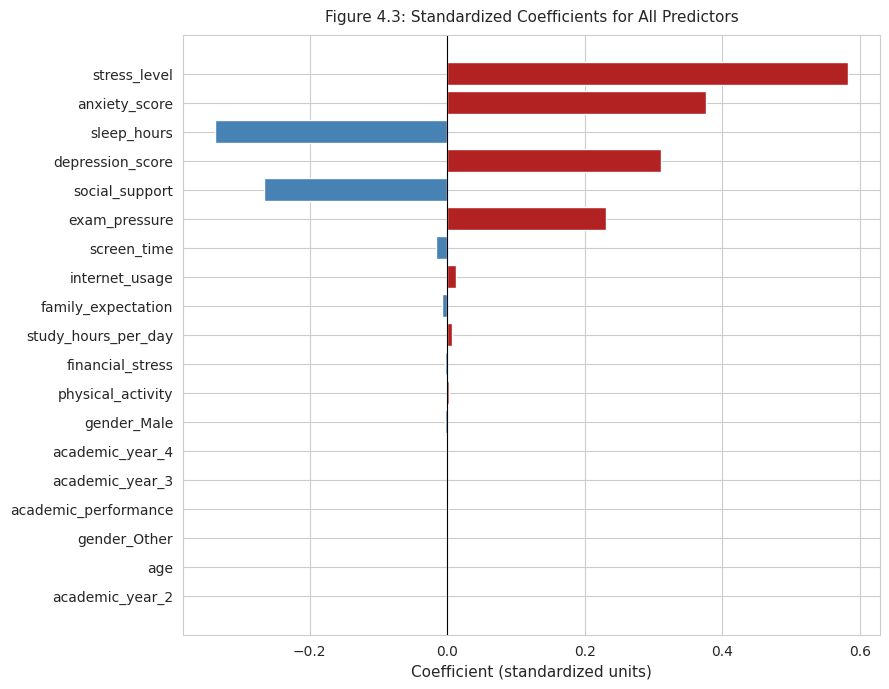

Saved: ../figures/ch04/figure_4_3_coefficients.png


In [18]:
# ── Figure 4.3: Horizontal bar chart of standardized coefficients ─────────────
# Coefficients from the scaled model are already on a comparable scale
# (standard deviations of X), so the bar lengths directly reflect relative
# importance. Positive bars mean higher burnout; negative bars mean lower burnout.

coef_sorted = coef_table.sort_values('Coefficient', key=abs, ascending=True)

colors = ['firebrick' if c > 0 else 'steelblue' for c in coef_sorted['Coefficient']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(coef_sorted['Feature'], coef_sorted['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (standardized units)', fontsize=11)
ax.set_title('Figure 4.3: Standardized Coefficients for All Predictors',
             fontsize=11, pad=10)
plt.tight_layout()
fig_path_43 = os.path.join(FIGURES_DIR, 'figure_4_3_coefficients.png')
plt.savefig(fig_path_43, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_43}')

---
## §6. Diagnostics and Tuning

In [19]:
# ── 10-Fold Cross-Validation ──────────────────────────────────────────────────
# Cross-validation splits the training set into 10 folds, trains on 9 and
# evaluates on 1, cycling through all folds. This confirms that the train/test
# metrics are not driven by a lucky random split.

cv_scores = cross_val_score(
    estimator=LinearRegression(),
    X=X_train,
    y=y_train,
    cv=10,
    scoring='r2',
    n_jobs=-1
)

cv_mean = round(cv_scores.mean(), 3)
cv_std  = round(cv_scores.std(),  3)

print('10-Fold CV R-squared scores (3 decimal places):')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i:2d}: {s:.3f}')
print()
print(f'CV Mean : {cv_mean}')
print(f'CV Std  : {cv_std}')

10-Fold CV R-squared scores (3 decimal places):
  Fold  1: 0.700
  Fold  2: 0.709
  Fold  3: 0.703
  Fold  4: 0.714
  Fold  5: 0.706
  Fold  6: 0.710
  Fold  7: 0.710
  Fold  8: 0.707
  Fold  9: 0.707
  Fold 10: 0.708

CV Mean : 0.707
CV Std  : 0.003


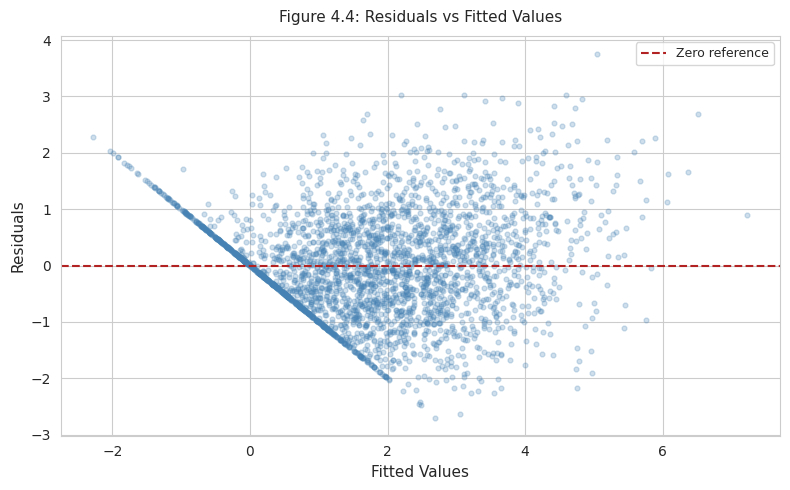

Saved: ../figures/ch04/figure_4_4_residuals.png
Note: figure shows 3,000 sample points for readability.
All residual statistics use the full training set.
Interpretation note: the diagonal lower boundary appears because burnout scores are bounded below at 0.
This does not invalidate the model, but it shows that the 0 to 10 outcome scale affects residual shape.


In [20]:
# ── Figure 4.4: Residuals vs Fitted Values ────────────────────────────────────
# Residuals = actual - predicted.
# A random scatter around the zero line suggests the linear model is appropriate.
# A fan shape suggests heteroscedasticity; a curve suggests a missed nonlinearity.
#
# A 3,000-point sample is used for display only. All residual statistics
# and diagnostics use the full training set.

residuals_train = y_train - y_pred_train

SAMPLE_N   = 3000
rng        = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(y_train), size=SAMPLE_N, replace=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    y_pred_train[sample_idx], residuals_train[sample_idx],
    alpha=0.25, s=12, color='steelblue'
)
ax.axhline(0, color='firebrick', linewidth=1.5, linestyle='--', label='Zero reference')
ax.set_xlabel('Fitted Values', fontsize=11)
ax.set_ylabel('Residuals', fontsize=11)
ax.set_title('Figure 4.4: Residuals vs Fitted Values', fontsize=11, pad=10)
ax.legend(fontsize=9)
plt.tight_layout()
fig_path_44 = os.path.join(FIGURES_DIR, 'figure_4_4_residuals.png')
plt.savefig(fig_path_44, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_44}')
print(f'Note: figure shows {SAMPLE_N:,} sample points for readability.')
print('All residual statistics use the full training set.')

print('Interpretation note: the diagonal lower boundary appears because burnout scores are bounded below at 0.')
print('This does not invalidate the model, but it shows that the 0 to 10 outcome scale affects residual shape.')


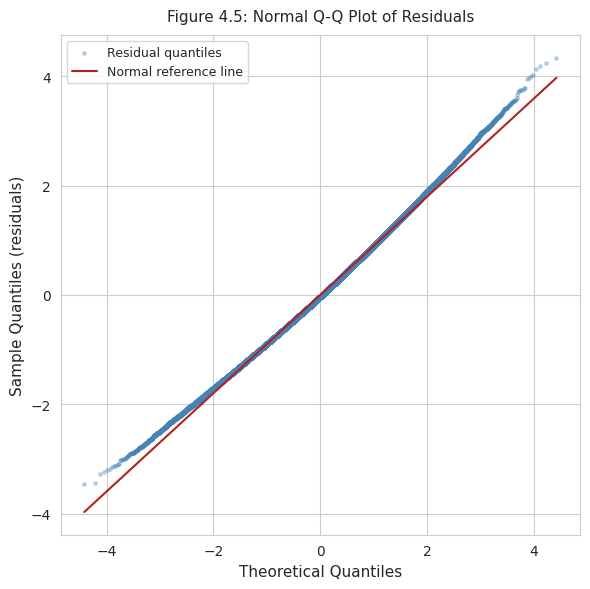

Saved: ../figures/ch04/figure_4_5_qq.png


In [21]:
# ── Figure 4.5: Normal Q-Q Plot of Residuals ──────────────────────────────────
# Compares the distribution of residuals to a theoretical normal distribution.
# Points close to the diagonal line indicate approximately normal residuals.
# This figure uses all training residuals.

fig, ax = plt.subplots(figsize=(6, 6))

(osm, osr), (slope_qq, intercept_qq, _) = stats.probplot(
    residuals_train, dist='norm'
)

ax.scatter(osm, osr, alpha=0.3, s=6, color='steelblue', label='Residual quantiles')
x_ref = np.array([osm.min(), osm.max()])
ax.plot(x_ref, slope_qq * x_ref + intercept_qq,
        color='firebrick', linewidth=1.5, label='Normal reference line')

ax.set_xlabel('Theoretical Quantiles', fontsize=11)
ax.set_ylabel('Sample Quantiles (residuals)', fontsize=11)
ax.set_title('Figure 4.5: Normal Q-Q Plot of Residuals', fontsize=11, pad=10)
ax.legend(fontsize=9)
plt.tight_layout()
fig_path_45 = os.path.join(FIGURES_DIR, 'figure_4_5_qq.png')
plt.savefig(fig_path_45, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_45}')

---
## §7. Findings

In [22]:
# ── Table 4.6: Summary of MLR Results ────────────────────────────────────────
# All values to exactly 3 decimal places as required by Chapter 4.

adj_r2  = round(ols_fit.rsquared_adj, 3)
f_stat  = round(ols_fit.fvalue,       3)

# Top 5 predictors by absolute coefficient magnitude
top5 = coef_table.sort_values('Coefficient', key=abs, ascending=False).head(5)
top5_str = ', '.join(
    f"{row['Feature']} ({row['Coefficient']:.3f})"
    for _, row in top5.iterrows()
)

results_data = {
    'Metric': [
        'Train R-squared',
        'Test R-squared',
        'Train RMSE',
        'Test RMSE',
        'Adjusted R-squared',
        'F-statistic',
        'CV R-squared (mean +/- std)',
        'Top 5 Predictors by |Coefficient|',
    ],
    'Value': [
        f'{train_r2:.3f}',
        f'{test_r2:.3f}',
        f'{train_rmse:.3f}',
        f'{test_rmse:.3f}',
        f'{adj_r2:.3f}',
        f'{f_stat:.3f}',
        f'{cv_mean:.3f} +/- {cv_std:.3f}',
        top5_str,
    ]
}

results_df = pd.DataFrame(results_data)

print('Table 4.6: Multiple Linear Regression -- Key Results')
print('=' * 70)
print(results_df.to_string(index=False))
print('=' * 70)

Table 4.6: Multiple Linear Regression -- Key Results
                           Metric                                                                                                                Value
                  Train R-squared                                                                                                                0.707
                   Test R-squared                                                                                                                0.707
                       Train RMSE                                                                                                                0.900
                        Test RMSE                                                                                                                0.900
               Adjusted R-squared                                                                                                                0.707
                      F-statistic        

In [23]:
# ── Save results to CSV ───────────────────────────────────────────────────────
csv_path = os.path.join(RESULTS_DIR, 'mlr_results.csv')
results_df.to_csv(csv_path, index=False)
print(f'Table 4.1 saved to: {csv_path}')

mlr_key_results_csv = os.path.join(RESULTS_DIR, 'table_4_6_mlr_key_results.csv')
results_df.to_csv(mlr_key_results_csv, index=False)
print(f'Table 4.6 copy saved to: {mlr_key_results_csv}')


Table 4.1 saved to: ../results/ch04/mlr_results.csv
Table 4.6 copy saved to: ../results/ch04/table_4_6_mlr_key_results.csv


---
## §8. Real-World Decision

The model shows that stress level, anxiety, and depression have the largest positive coefficients, while sleep hours and social support have the strongest negative coefficients. A university wellness office looking to act on these results should focus early outreach on students who score high on psychological distress indicators and low on protective factors such as sleep and support. Academic variables like exam pressure also contribute, so advising support during high-pressure periods would complement a mental-health-focused intervention. Gender and academic year show smaller effects, which means they are less useful on their own for targeting. Because the data source does not clearly confirm how the records were collected or created, the specific coefficient values should not be treated as direct evidence for real student populations without outside validation.

---
## §9. Caveats and Limitations

Even after flagging high-VIF features, some multicollinearity remains between stress, anxiety, and depression, which are conceptually overlapping constructs. This means the individual coefficients for those variables should be interpreted with caution because part of their effect is shared. Since the data source does not clearly confirm how the records were collected or created, the strong R-squared values should be treated as evidence of model performance on this dataset, not as confirmed real-world student behavior. As with Chapter 3, the model captures associations, not causal relationships, so higher stress scores being linked to higher burnout does not prove that reducing stress alone would directly lower burnout.

In [24]:
# ── Final summary ─────────────────────────────────────────────────────────────

print('Chapter 4 complete. Files written:')
print()

print('Main chapter figures')
for p in [fig_path_41, fig_path_42, fig_path_43, fig_path_44, fig_path_45]:
    print(f' {p}')

print()

print('Appendix C figures')
for p in [fig_app_c41, fig_app_c42, fig_app_c43]:
    print(f' {p}')

print()

print('Main results and tables')
for p in [
    csv_path,
    mlr_key_results_csv,
    vif_high_csv,
    comparison_csv,
    coef_top_csv
]:
    print(f' {p}')

print()

print('Appendix C tables')
for p in [
    vif_full_csv,
    subset_csv,
    best_subset_csv,
    bwd_csv,
    coef_csv
]:
    print(f' {p}')

Chapter 4 complete. Files written:

Main chapter figures
 ../figures/ch04/figure_4_1_vif.png
 ../figures/ch04/figure_4_2_aic_bic_selection.png
 ../figures/ch04/figure_4_3_coefficients.png
 ../figures/ch04/figure_4_4_residuals.png
 ../figures/ch04/figure_4_5_qq.png

Appendix C figures
 ../figures/ch04/appendix_c_4_1_greedy_best_subset_bic.png
 ../figures/ch04/appendix_c_4_2_backward_stepwise_bic.png
 ../figures/ch04/appendix_c_4_3_forward_stepwise_bic.png

Main results and tables
 ../results/ch04/mlr_results.csv
 ../results/ch04/table_4_6_mlr_key_results.csv
 ../results/ch04/vif_high_predictors.csv
 ../results/ch04/table_4_4_subset_comparison.csv
 ../results/ch04/top_standardized_coefficients.csv

Appendix C tables
 ../results/ch04/vif_full_table_appendix.csv
 ../results/ch04/subset_selection.csv
 ../results/ch04/greedy_best_subset_table_appendix.csv
 ../results/ch04/backward_stepwise_table_appendix.csv
 ../results/ch04/coefficients_full_table_appendix.csv
